In [3]:
# ================================
# Federated Learning with XGBoost
# ================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle
import warnings
warnings.filterwarnings("ignore")

# ========== Load and Prepare Data ==========
train_path = r"C:\Users\Aswathi M\Downloads\combined_train.csv"
test_path = r"C:\Users\Aswathi M\Downloads\combined_test.csv"

df_train = pd.read_csv(train_path)
df_test = pd.read_csv(test_path)

# Encode categorical features
def encode_categoricals(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = LabelEncoder().fit_transform(df[col])
    return df

df_train = encode_categoricals(df_train)
df_test = encode_categoricals(df_test)

# Shuffle train data
df_train = shuffle(df_train, random_state=42)

# Split into X and y
X_train = df_train.drop('label', axis=1)
y_train = df_train['label']
X_test = df_test.drop('label', axis=1)
y_test = df_test['label']

# ========== Simulate Federated Clients ==========
num_clients = 3
client_data = np.array_split(X_train, num_clients)
client_labels = np.array_split(y_train, num_clients)

client_models = []
num_classes = len(np.unique(y_train))
probs = np.zeros((X_test.shape[0], num_classes))

# ========== Train Local Models ==========
for i in range(num_clients):
    print(f"Training XGBoost model for client {i+1}...")

    dtrain = xgb.DMatrix(client_data[i], label=client_labels[i])
    dtest = xgb.DMatrix(X_test)

    params = {
        'objective': 'multi:softprob',
        'num_class': num_classes,
        'max_depth': 6,
        'eta': 0.1,
        'eval_metric': 'mlogloss',
        'verbosity': 0
    }

    bst = xgb.train(params, dtrain, num_boost_round=200)
    client_models.append(bst)

    probs += bst.predict(dtest)

# ========== Average Predictions ==========
probs /= num_clients
y_pred = np.argmax(probs, axis=1)

# ========== Evaluation ==========
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("F1 Score (macro):", f1_score(y_test, y_pred, average='macro'))


Training XGBoost model for client 1...
Training XGBoost model for client 2...
Training XGBoost model for client 3...

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1500
           1       1.00      1.00      1.00      1500
           2       1.00      1.00      1.00      1500
           3       0.99      0.99      0.99      1500

    accuracy                           0.99      6000
   macro avg       0.99      0.99      0.99      6000
weighted avg       0.99      0.99      0.99      6000

=== Confusion Matrix ===
[[1486    0    0   14]
 [   0 1499    1    0]
 [   0    2 1498    0]
 [  22    0    0 1478]]
F1 Score (macro): 0.9934999572774743


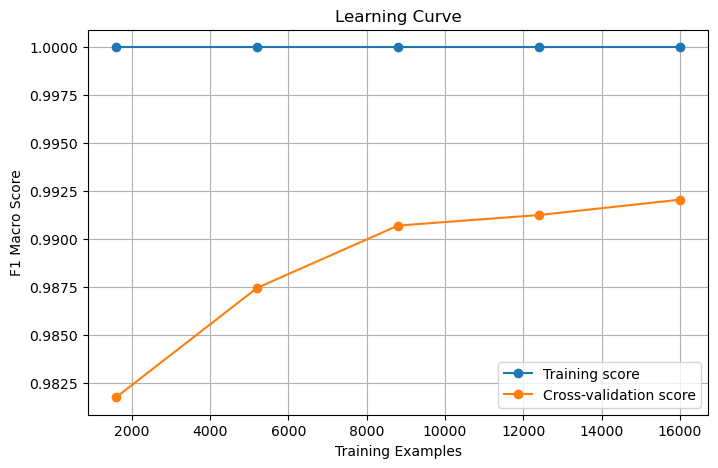

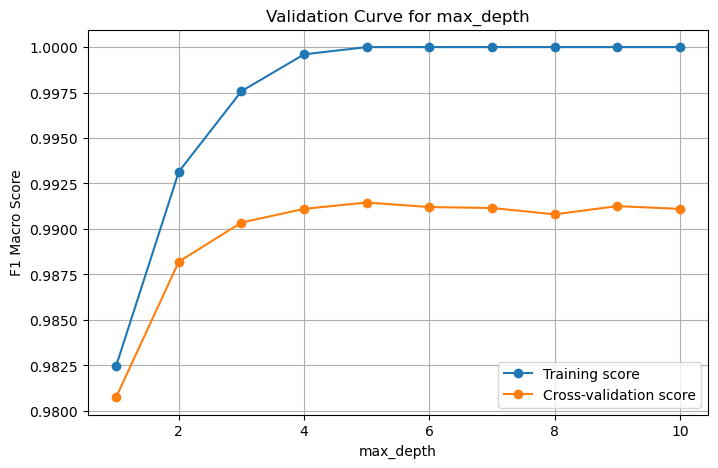

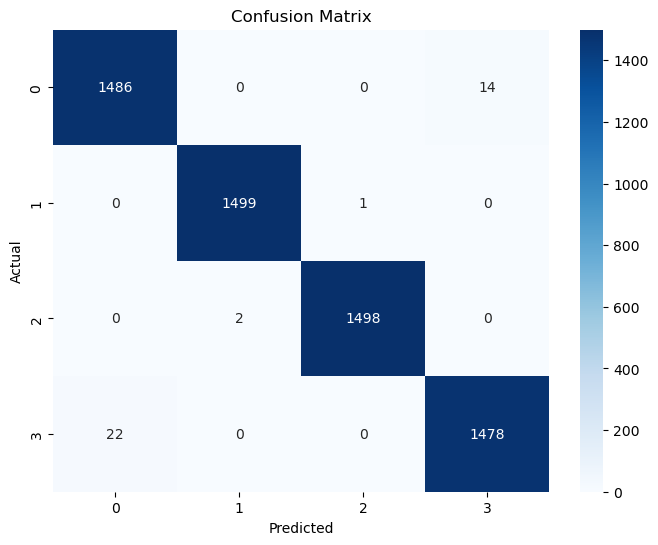

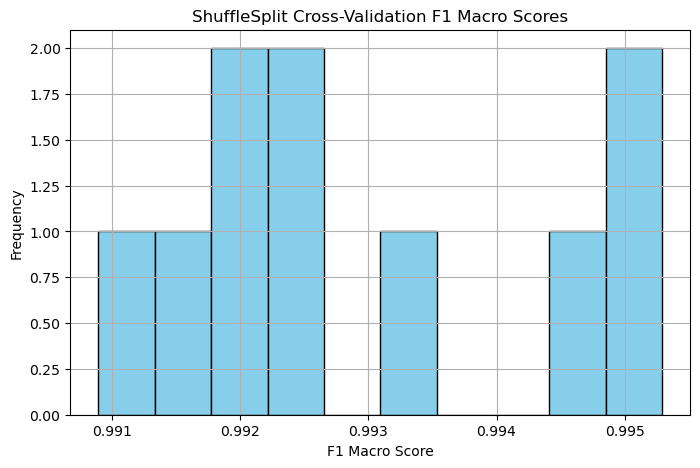

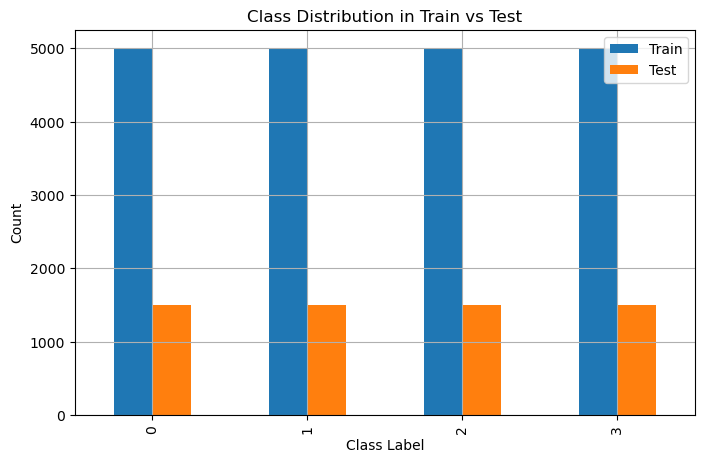

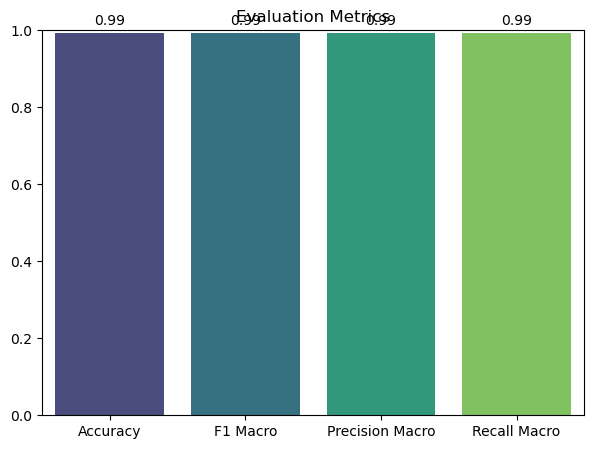

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve, validation_curve, ShuffleSplit, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import numpy as np
import xgboost as xgb

# ===================================
# Learning Curve
# ===================================
def plot_learning_curve(estimator, X, y, title='Learning Curve'):
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=5, scoring='f1_macro', n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )
    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_mean, 'o-', label='Training score')
    plt.plot(train_sizes, test_mean, 'o-', label='Cross-validation score')
    plt.title(title)
    plt.xlabel('Training Examples')
    plt.ylabel('F1 Macro Score')
    plt.legend()
    plt.grid(True)
    plt.show()

# ===================================
# Validation Curve
# ===================================
def plot_validation_curve(param_name='max_depth', param_range=range(1, 11)):
    estimator = xgb.XGBClassifier(objective='multi:softprob', num_class=num_classes)
    train_scores, test_scores = validation_curve(
        estimator, X_train, y_train,
        param_name=param_name, param_range=param_range,
        cv=3, scoring='f1_macro', n_jobs=-1
    )

    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure(figsize=(8, 5))
    plt.plot(param_range, train_mean, 'o-', label='Training score')
    plt.plot(param_range, test_mean, 'o-', label='Cross-validation score')
    plt.title(f'Validation Curve for {param_name}')
    plt.xlabel(param_name)
    plt.ylabel('F1 Macro Score')
    plt.legend()
    plt.grid(True)
    plt.show()

# ===================================
# Confusion Matrix Heatmap
# ===================================
def plot_conf_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# ===================================
# ShuffleSplit + Histogram of Scores
# ===================================
def plot_shuffle_split_hist():
    estimator = xgb.XGBClassifier(objective='multi:softprob', num_class=num_classes)
    cv = ShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
    scores = cross_val_score(estimator, X_train, y_train, cv=cv, scoring='f1_macro')

    plt.figure(figsize=(8, 5))
    plt.hist(scores, bins=10, color='skyblue', edgecolor='black')
    plt.title("ShuffleSplit Cross-Validation F1 Macro Scores")
    plt.xlabel("F1 Macro Score")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.show()

# ===================================
# Bar Chart of Class Distribution
# ===================================
def plot_class_distribution(y_train, y_test):
    train_dist = y_train.value_counts().sort_index()
    test_dist = y_test.value_counts().sort_index()

    df_plot = pd.DataFrame({'Train': train_dist, 'Test': test_dist})
    df_plot.plot(kind='bar', figsize=(8, 5))
    plt.title("Class Distribution in Train vs Test")
    plt.xlabel("Class Label")
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

# ===================================
# Evaluation Metric Plot
# ===================================
def plot_eval_metrics(y_true, y_pred):
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'F1 Macro': f1_score(y_true, y_pred, average='macro'),
        'Precision Macro': precision_score(y_true, y_pred, average='macro'),
        'Recall Macro': recall_score(y_true, y_pred, average='macro')
    }

    plt.figure(figsize=(7, 5))
    sns.barplot(x=list(metrics.keys()), y=list(metrics.values()), palette="viridis")
    plt.title("Evaluation Metrics")
    plt.ylim(0, 1)
    for i, v in enumerate(metrics.values()):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
    plt.show()

# ===================================
# Call All Plots
# ===================================
# Wrap XGBoost model
model_for_curve = xgb.XGBClassifier(objective='multi:softprob', num_class=num_classes)
plot_learning_curve(model_for_curve, X_train.values, y_train.values)
plot_validation_curve()
plot_conf_matrix(y_test, y_pred)
plot_shuffle_split_hist()
plot_class_distribution(y_train, y_test)
plot_eval_metrics(y_test, y_pred)
